<a href="https://colab.research.google.com/github/blackArcher33/Day2_Assignment_EXL/blob/main/345375(Jatin)_345369(Aryan).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Import Libraries**

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

**EDA**

In [ ]:
df = pd.read_csv("diabetes_prediction_dataset.csv")
df

,gender,age,hypertension,heart_disease,smoking_history,bmi,HbA1c_level,blood_glucose_level,diabetes
0,Female,80.0,0,1,never,25.19,6.6,140,0
1,Female,54.0,0,0,No Info,27.32,6.6,80,0
2,Male,28.0,0,0,never,27.32,5.7,158,0
3,Female,36.0,0,0,current,23.45,5.0,155,0
4,Male,76.0,1,1,current,20.14,4.8,155,0
...,...,...,...,...,...,...,...,...,...
99995,Female,80.0,0,0,No Info,27.32,6.2,90,0
99996,Female,2.0,0,0,No Info,17.37,6.5,100,0
99997,Male,66.0,0,0,former,27.83,5.7,155,0
99998,Female,24.0,0,0,never,35.42,4.0,100,0


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 9 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   gender               100000 non-null  object 
 1   age                  100000 non-null  float64
 2   hypertension         100000 non-null  int64  
 3   heart_disease        100000 non-null  int64  
 4   smoking_history      100000 non-null  object 
 5   bmi                  100000 non-null  float64
 6   HbA1c_level          100000 non-null  float64
 7   blood_glucose_level  100000 non-null  int64  
 8   diabetes             100000 non-null  int64  
dtypes: float64(3), int64(4), object(2)
memory usage: 6.9+ MB


In [ ]:
df.head()

,gender,age,hypertension,heart_disease,smoking_history,bmi,HbA1c_level,blood_glucose_level,diabetes
0,Female,80.0,0,1,never,25.19,6.6,140,0
1,Female,54.0,0,0,No Info,27.32,6.6,80,0
2,Male,28.0,0,0,never,27.32,5.7,158,0
3,Female,36.0,0,0,current,23.45,5.0,155,0
4,Male,76.0,1,1,current,20.14,4.8,155,0


In [ ]:
df.describe()

,age,hypertension,heart_disease,bmi,HbA1c_level,blood_glucose_level,diabetes
count,100000.000000,100000.00000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000
mean,41.885856,0.07485,0.039420,27.320767,5.527507,138.058060,0.085000
std,22.516840,0.26315,0.194593,6.636783,1.070672,40.708136,0.278883
min,0.080000,0.00000,0.000000,10.010000,3.500000,80.000000,0.000000
25%,24.000000,0.00000,0.000000,23.630000,4.800000,100.000000,0.000000
50%,43.000000,0.00000,0.000000,27.320000,5.800000,140.000000,0.000000
75%,60.000000,0.00000,0.000000,29.580000,6.200000,159.000000,0.000000
max,80.000000,1.00000,1.000000,95.690000,9.000000,300.000000,1.000000


In [ ]:
df["smoking_history"].unique()

array(['never', 'No Info', 'current', 'former', 'ever', 'not current'],
      dtype=object)

In [ ]:
df.drop_duplicates(inplace = True)
df.duplicated().sum()

np.int64(0)

In [ ]:
df["hypertension"]= df["hypertension"].map({ 0 : "absence" , 1: "presence"})

In [ ]:
df["heart_disease"]= df["heart_disease"].map({ 0 : "absence" , 1 : "presence"})

In [ ]:
df["diabetes"]= df["diabetes"].map({ 0 : "absence" , 1 : "presence"})

In [ ]:
df["smoking_history"] = df["smoking_history"].map({
    'never': 'never',
    'No Info': 'unknown',
    'current': 'current',
    'ever': 'current',
    'former': 'former',
    'not current': 'former'}
)

In [ ]:
df

,gender,age,hypertension,heart_disease,smoking_history,bmi,HbA1c_level,blood_glucose_level,diabetes
0,Female,80.0,absence,presence,never,25.19,6.6,140,absence
1,Female,54.0,absence,absence,unknown,27.32,6.6,80,absence
2,Male,28.0,absence,absence,never,27.32,5.7,158,absence
3,Female,36.0,absence,absence,current,23.45,5.0,155,absence
4,Male,76.0,presence,presence,current,20.14,4.8,155,absence
...,...,...,...,...,...,...,...,...,...
99994,Female,36.0,absence,absence,unknown,24.60,4.8,145,absence
99996,Female,2.0,absence,absence,unknown,17.37,6.5,100,absence
99997,Male,66.0,absence,absence,former,27.83,5.7,155,absence
99998,Female,24.0,absence,absence,never,35.42,4.0,100,absence


In [ ]:
df["age"].agg(["max", "mean", "min"]).to_frame()

,age
max,80.000000
mean,41.794326
min,0.080000


In [ ]:
df["bmi"].agg(["max","mean","min"]).to_frame()

,bmi
max,95.690000
mean,27.321461
min,10.010000


In [ ]:
df[df["bmi"] >= 95]

,gender,age,hypertension,heart_disease,smoking_history,bmi,HbA1c_level,blood_glucose_level,diabetes
76093,Male,16.0,absence,absence,unknown,95.22,4.5,90,absence
87843,Male,7.0,absence,absence,unknown,95.69,6.1,130,absence


In [ ]:
df["blood_glucose_level"].agg(["max","mean","min"]).to_frame()

,blood_glucose_level
max,300.000000
mean,138.218231
min,80.000000


In [ ]:
df["HbA1c_level"].agg(["max","mean","min"]).to_frame()

,HbA1c_level
max,9.000000
mean,5.532609
min,3.500000


In [ ]:
df.groupby("gender")["diabetes"].value_counts().reset_index(name="count")


,gender,diabetes,count
0,Female,absence,51714
1,Female,presence,4447
2,Male,absence,35932
3,Male,presence,4035
4,Other,absence,18


In [ ]:
df.groupby("hypertension") ["diabetes"].value_counts().to_frame()

count
hypertension diabetes       
absence      absence   82289
             presence   6396
presence     absence    5375
             presence   2086

In [ ]:
df.groupby("heart_disease") ["diabetes"].value_counts().to_frame()

count
heart_disease diabetes       
absence       absence   85008
              presence   7215
presence      absence    2656
              presence   1267

In [ ]:
df.groupby("smoking_history") ["diabetes"].value_counts().to_frame()

count
smoking_history diabetes       
current         absence   11775
                presence   1420
former          absence   13386
                presence   2280
never           absence   31061
                presence   3337
unknown         absence   31442
                presence   1445

In [ ]:
df.groupby("smoking_history") ["heart_disease"].value_counts().to_frame()

count
smoking_history heart_disease       
current         absence        12473
                presence         722
former          absence        14468
                presence        1198
never           absence        33302
                presence        1096
unknown         absence        31980
                presence         907

**Data Visualisation**

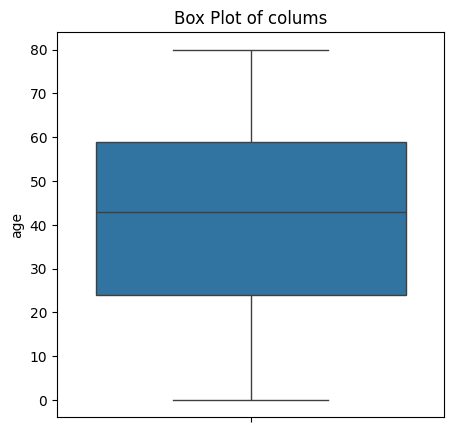

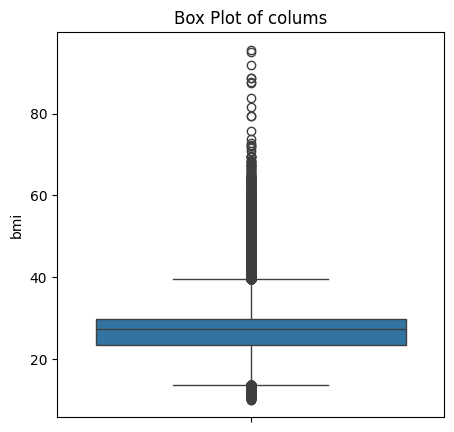

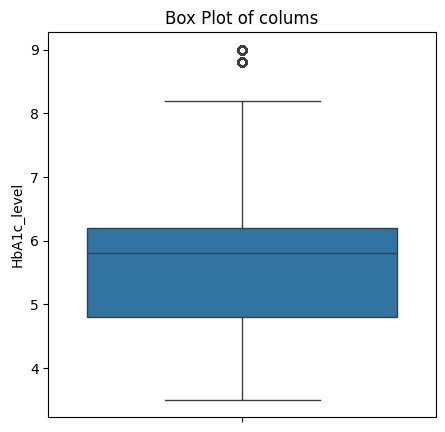

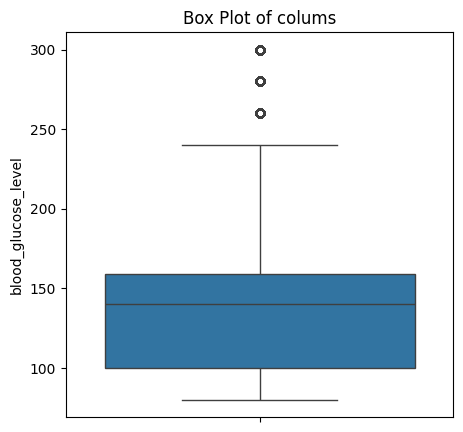

In [ ]:
cols = ['age', 'bmi', 'HbA1c_level', 'blood_glucose_level']
for col in cols:
    plt.figure(figsize=(5, 5))
    sns.boxplot(y=df[col])
    plt.title('Box Plot of colums')
    plt.ylabel(col)
plt.show()

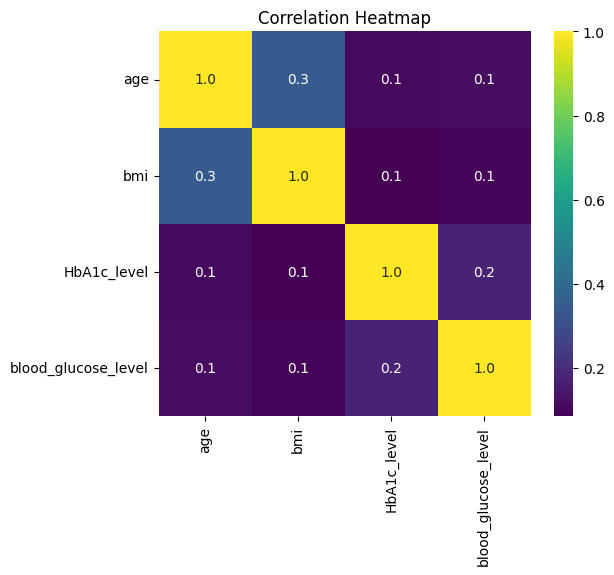

In [ ]:
corr = df.select_dtypes(include=['number']).corr()
plt.figure(figsize=(6, 5))
sns.heatmap(corr, annot=True, cmap='viridis', fmt=".1f")
plt.title('Correlation Heatmap')
plt.show()

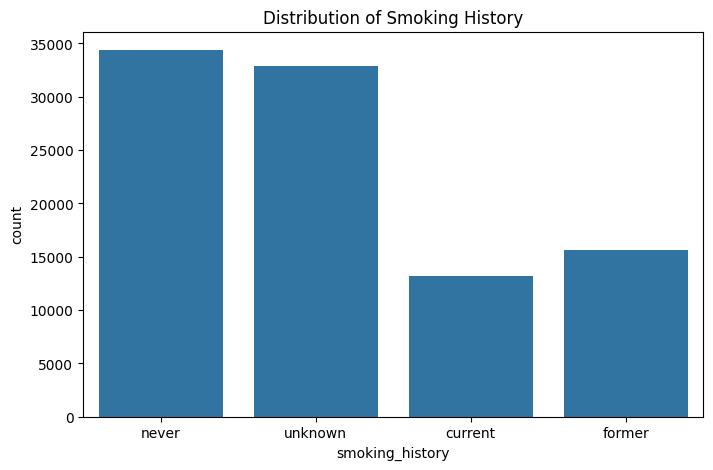

In [ ]:
plt.figure(figsize=(8, 5))
sns.countplot(x='smoking_history', data=df)
plt.title('Distribution of Smoking History')
plt.show()

([<matplotlib.patches.Wedge at 0x7be14412e360>,
 [Text(-0.2873328614358225, 1.06180969421978, 'Female'),
  Text(0.2867082442370545, -1.0619785227049112, 'Male'),
  Text(1.0999998099925337, -0.0006465418703282869, 'Other')],
 [Text(-0.15672701532863043, 0.57916892411988, '58.4%'),
  Text(0.15638631503839334, -0.579261012384497, '41.6%'),
  Text(0.5999998963595637, -0.00035265920199724734, '0.0%')])

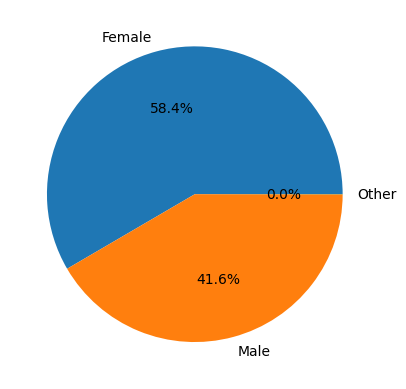

In [ ]:
plt.pie(df['gender'].value_counts(), labels=df['gender'].unique(), autopct='%1.1f%%')

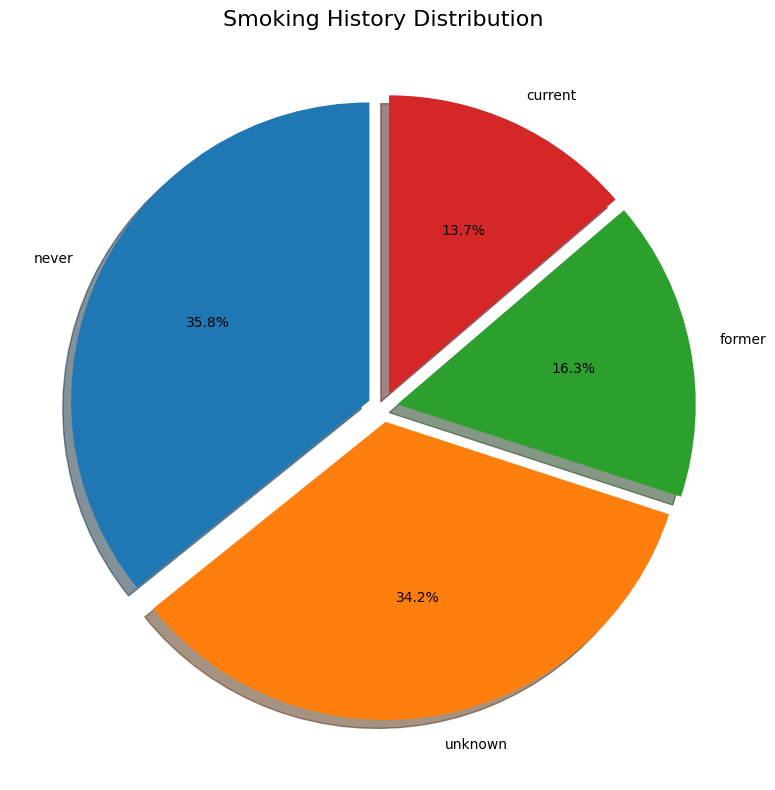

In [ ]:
counts = df["smoking_history"].value_counts()

plt.figure(figsize=(8,8))
plt.pie(
    counts,
    labels=counts.index,
    autopct='%1.1f%%',
    startangle=90,
    explode=[0.05]*len(counts),
    shadow=True
)

plt.title("Smoking History Distribution", fontsize=16)
plt.tight_layout()
plt.show()

Text(0.5, 1.0, 'BMI Distribution')

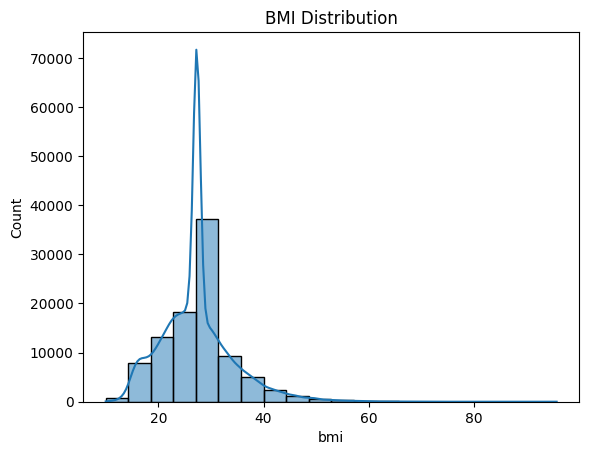

In [ ]:
sns.histplot(data=df, x='bmi', kde=True, bins=20)
plt.title('BMI Distribution')

**ML models**

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [ ]:
X = df.drop("diabetes", axis=1)
y = df["diabetes"]

**Data Split**

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

**Random Forest**

In [ ]:
rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

In [ ]:
categorical_cols = ['gender', 'hypertension', 'heart_disease', 'smoking_history']
X_train = pd.get_dummies(X_train, columns=categorical_cols, drop_first=True)

rf.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [ ]:
X_test = pd.get_dummies(X_test, columns=categorical_cols, drop_first=True)
y_pred = rf.predict(X_test)

In [ ]:
print("Accuracy:", accuracy_score(y_test, y_pred))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Accuracy: 0.9693707748309932

Confusion Matrix:
[[17471    63]
 [  526  1170]]

Classification Report:
              precision    recall  f1-score   support

     absence       0.97      1.00      0.98     17534
    presence       0.95      0.69      0.80      1696

    accuracy                           0.97     19230
   macro avg       0.96      0.84      0.89     19230
weighted avg       0.97      0.97      0.97     19230



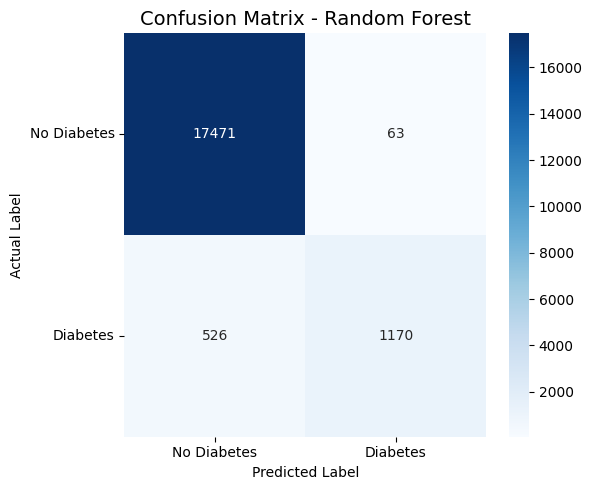

In [ ]:
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

# Plot
plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,        # Show numbers in cells
    fmt='d',           # Integer format
    cmap='Blues',      # Color scheme
    cbar=True
)

plt.title('Confusion Matrix - Random Forest', fontsize=14)
plt.xlabel('Predicted Label')
plt.ylabel('Actual Label')

plt.xticks([0.5, 1.5], ['No Diabetes', 'Diabetes'])
plt.yticks([0.5, 1.5], ['No Diabetes', 'Diabetes'], rotation=0)

plt.tight_layout()
plt.show()

**LogisticRegression**

In [ ]:
from sklearn.linear_model import LogisticRegression

In [ ]:
lr = LogisticRegression(
    max_iter=1000,
    random_state=42
)

lr.fit(X_train, y_train)

LogisticRegression(max_iter=1000, random_state=42)

In [ ]:
y_pred_lr = lr.predict(X_test)

In [ ]:
accuracy = accuracy_score(y_test, y_pred_lr)
print("Logistic Regression Accuracy:", round(accuracy * 100, 2), "%")

Logistic Regression Accuracy: 95.98 %


In [ ]:
print(classification_report(y_test, y_pred_lr))

              precision    recall  f1-score   support

     absence       0.97      0.99      0.98     17534
    presence       0.87      0.64      0.74      1696

    accuracy                           0.96     19230
   macro avg       0.92      0.81      0.86     19230
weighted avg       0.96      0.96      0.96     19230



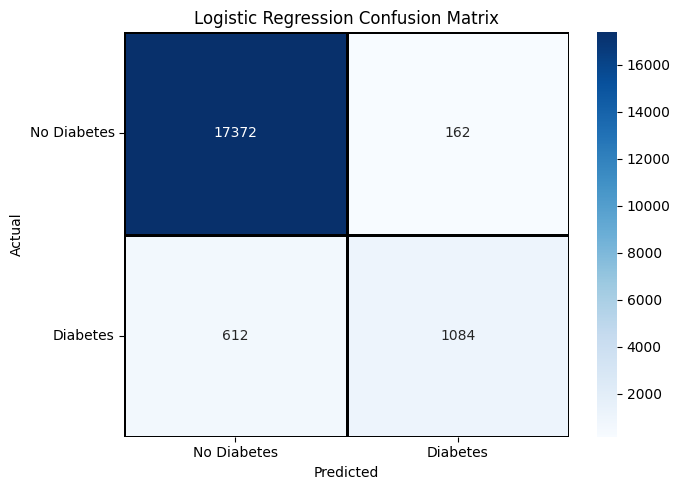

In [ ]:
cm_lr = confusion_matrix(y_test, y_pred_lr)

plt.figure(figsize=(7,5))

sns.heatmap(
    cm_lr,
    annot=True,
    fmt='d',
    cmap='Blues',
    linewidths=1,
    linecolor='black'
)

plt.title('Logistic Regression Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')

plt.xticks([0.5, 1.5], ['No Diabetes', 'Diabetes'])
plt.yticks([0.5, 1.5], ['No Diabetes', 'Diabetes'], rotation=0)

plt.tight_layout()
plt.show()

**DecisionTree**

In [ ]:
from sklearn.tree import DecisionTreeClassifier

In [ ]:
dt = DecisionTreeClassifier(
    criterion='gini',
    max_depth=5,
    random_state=42
)

dt.fit(X_train, y_train)

DecisionTreeClassifier(max_depth=5, random_state=42)

In [ ]:
y_pred_dt = dt.predict(X_test)

In [ ]:
accuracy_dt = accuracy_score(y_test, y_pred_dt)

print("Decision Tree Accuracy:",
      round(accuracy_dt * 100, 2), "%")

Decision Tree Accuracy: 97.16 %


In [ ]:
print(classification_report(y_test, y_pred_dt))

              precision    recall  f1-score   support

     absence       0.97      1.00      0.98     17534
    presence       1.00      0.68      0.81      1696

    accuracy                           0.97     19230
   macro avg       0.98      0.84      0.90     19230
weighted avg       0.97      0.97      0.97     19230



In [ ]:
cm_dt = confusion_matrix(y_test, y_pred_dt)
print(cm_dt)

[[17534     0]
 [  546  1150]]


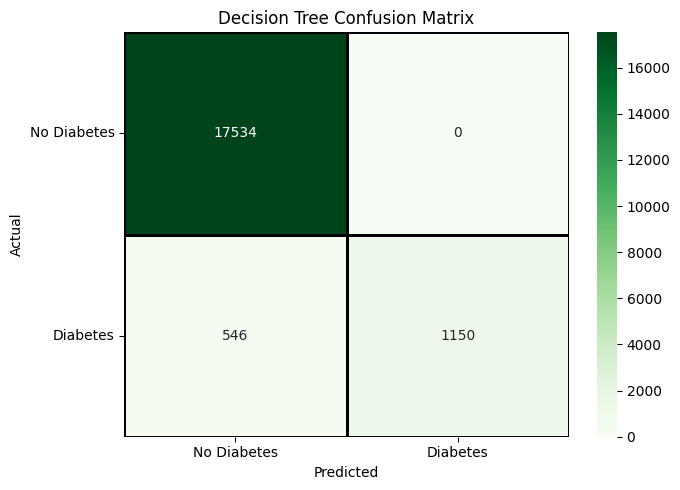

In [ ]:
plt.figure(figsize=(7,5))

sns.heatmap(
    cm_dt,
    annot=True,
    fmt='d',
    cmap='Greens',
    linewidths=1,
    linecolor='black'
)

plt.title("Decision Tree Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.xticks([0.5, 1.5], ["No Diabetes", "Diabetes"])
plt.yticks([0.5, 1.5], ["No Diabetes", "Diabetes"], rotation=0)

plt.tight_layout()
plt.show()

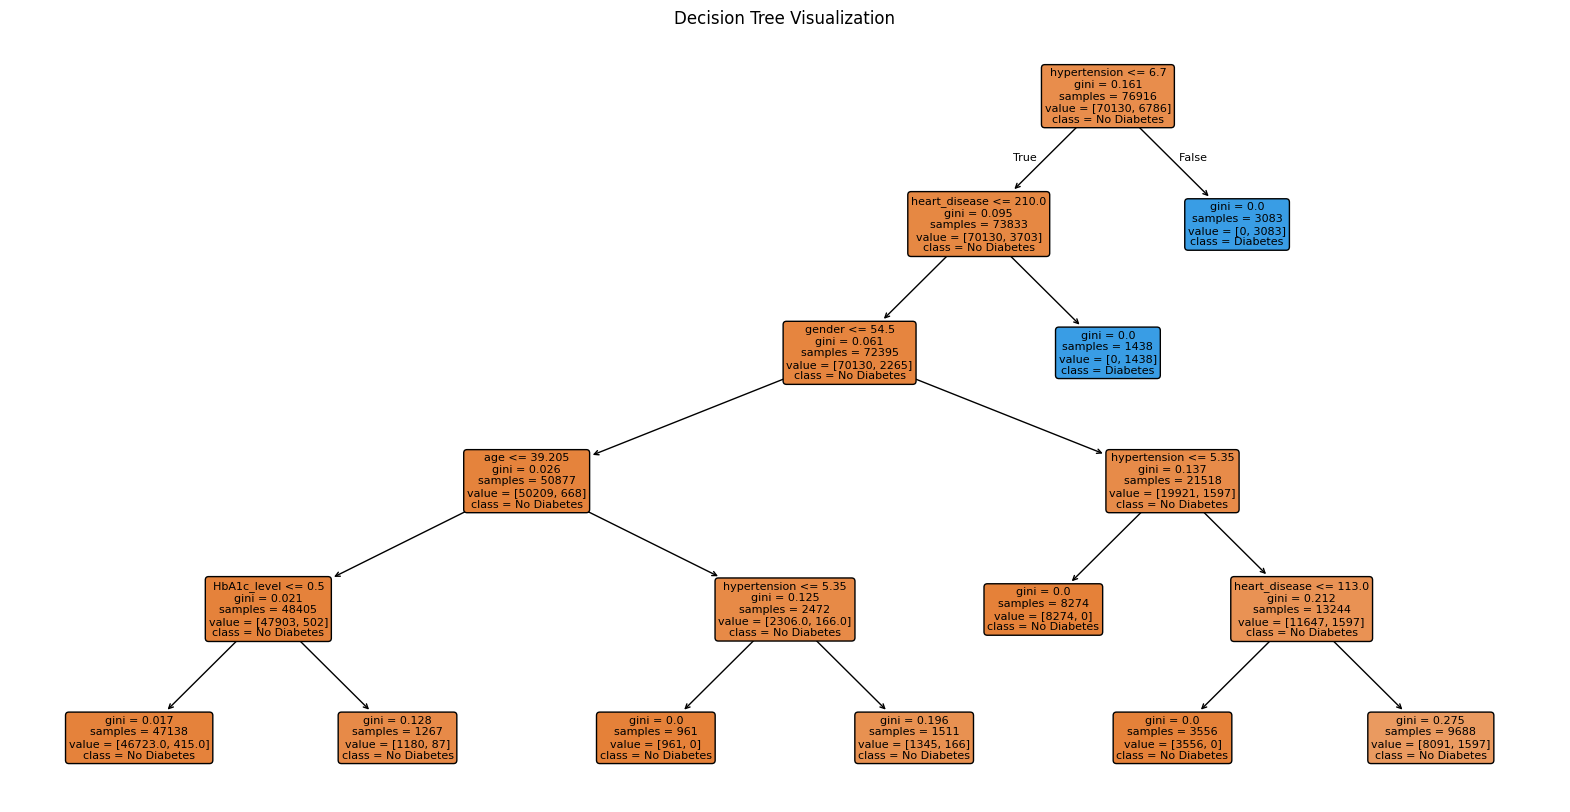

In [ ]:
from sklearn.tree import plot_tree

plt.figure(figsize=(20,10))

plot_tree(
    dt,
    feature_names=X.columns,
    class_names=["No Diabetes", "Diabetes"],
    filled=True,
    rounded=True,
    fontsize=8
)

plt.title("Decision Tree Visualization")
plt.show()

**models comparision**

In [ ]:
from sklearn.metrics import accuracy_score

rf_acc = accuracy_score(y_test, y_pred)
lr_acc = accuracy_score(y_test, y_pred_lr)
dt_acc = accuracy_score(y_test, y_pred_dt)

comparison = pd.DataFrame({
    "Model": ["Random Forest", "Logistic Regression", "Decision Tree"],
    "Accuracy": [rf_acc, lr_acc, dt_acc]
})

print(comparison)

                 Model  Accuracy
0        Random Forest  0.969371
1  Logistic Regression  0.959750
2        Decision Tree  0.971607


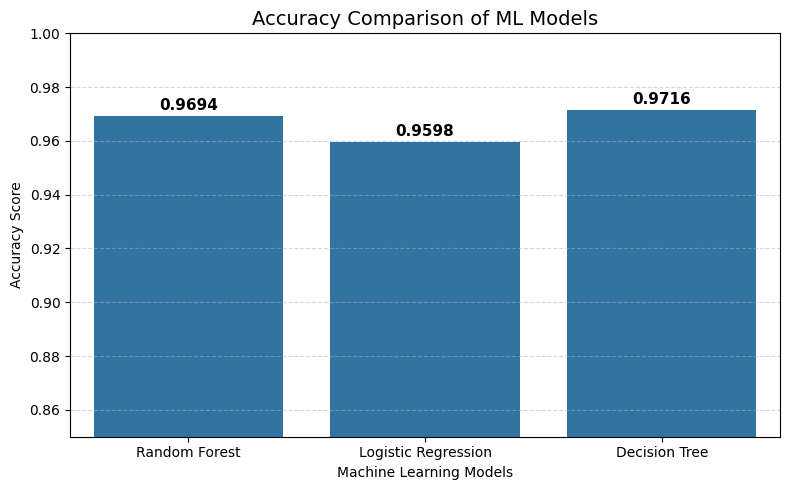

In [ ]:
plt.figure(figsize=(8,5))

ax = sns.barplot(
    data=comparison,
    x="Model",
    y="Accuracy"
)

# Display accuracy values on bars
for i, v in enumerate(comparison["Accuracy"]):
    ax.text(
        i,
        v + 0.002,
        f"{v:.4f}",
        ha='center',
        fontsize=11,
        fontweight='bold'
    )

plt.title("Accuracy Comparison of ML Models", fontsize=14)
plt.xlabel("Machine Learning Models")
plt.ylabel("Accuracy Score")
plt.ylim(0.85, 1.0)

plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

In [ ]:
from sklearn.metrics import precision_score, recall_score, f1_score

metrics_df = pd.DataFrame({
    "Model": ["Random Forest", "Logistic Regression", "Decision Tree"],
    "Accuracy": [
        accuracy_score(y_test, y_pred),
        accuracy_score(y_test, y_pred_lr),
        accuracy_score(y_test, y_pred_dt)
    ],
    "Precision": [
        precision_score(y_test, y_pred, pos_label='presence'),
        precision_score(y_test, y_pred_lr, pos_label='presence'),
        precision_score(y_test, y_pred_dt, pos_label='presence')
    ],
    "Recall": [
        recall_score(y_test, y_pred, pos_label='presence'),
        recall_score(y_test, y_pred_lr, pos_label='presence'),
        recall_score(y_test, y_pred_dt, pos_label='presence')
    ],
    "F1-Score": [
        f1_score(y_test, y_pred, pos_label='presence'),
        f1_score(y_test, y_pred_lr, pos_label='presence'),
        f1_score(y_test, y_pred_dt, pos_label='presence')
    ]
})

print(metrics_df)

                 Model  Accuracy  Precision    Recall  F1-Score
0        Random Forest  0.969371   0.948905  0.689858  0.798907
1  Logistic Regression  0.959750   0.869984  0.639151  0.736914
2        Decision Tree  0.971607   1.000000  0.678066  0.808152


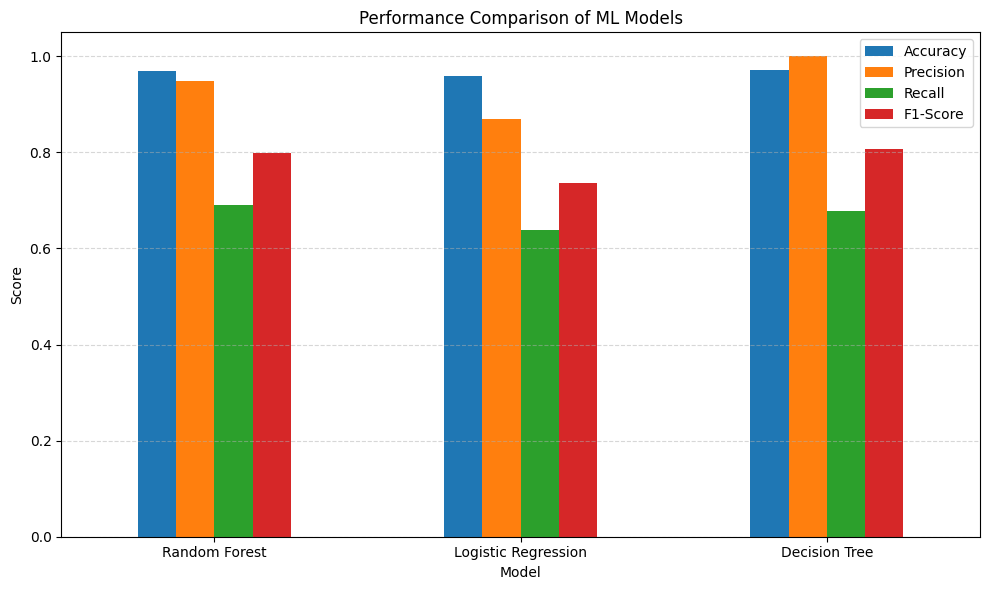

In [ ]:
metrics_df.set_index("Model").plot(
    kind="bar",
    figsize=(10,6)
)

plt.title("Performance Comparison of ML Models")
plt.ylabel("Score")
plt.ylim(0, 1.05)
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()